# Praktikum 5: Benchmark ANN (Recall vs Speed Trade-off)

In [ ]:
!pip install annoy faiss-cpu hnswlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 23.9 MB/s eta 0:00:00
  Created wheel for annoy: filename=annoy-1.17.3-cp313-cp313-linux_x86_64.whl size=520037 sha256=bacbac95c64cbb1f9d7a033a9abbe38179c18b14425e2650ec56fb45b3c571ed
  Stored in directory: /root/.cache/pip/wheels/fc/4e/87/f1f957e7382aa370452cff98276f51686924d5415e449800ed
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp313-cp313-linux_x86_64.whl size=2679798 sha256=ea656e5348a4607062273a9b5bb919502b388f50df2210e4739432fddd204227
  Stored in directory: /root/.cache/pip/wheels/35/04/88/b31765a4b9957705e18065db4657e61fc8da54f50e3ef0b67e
Successfully built annoy hnswlib


In [ ]:
import numpy as np
import time
import faiss
from annoy import AnnoyIndex
import hnswlib
import matplotlib.pyplot as plt

# 1. Dataset Random 128 Dimensi (100.000 data vector, 1.000 query vector)
d = 128        # Dimensi
nb = 100000    # Jumlah database vector
nq = 1000      # Jumlah query

np.random.seed(42)
xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

# 2. Hitung Ground Truth menggunakan FAISS Brute Force (Exact NN)
index_flat = faiss.IndexFlatL2(d)
index_flat.add(xb)
k = 10
_, gt_idx = index_flat.search(xq, k)

# 3. Fungsi Penghitung Recall@k
def recall_at_k(I_pred, I_gt, k):
    correct = 0
    for i in range(len(I_pred)):
        correct += len(set(I_pred[i][:k]) & set(I_gt[i][:k]))
    return correct / (len(I_pred) * k)

Running Annoy Benchmark...
Running FAISS Benchmark...
Running HNSW Benchmark...


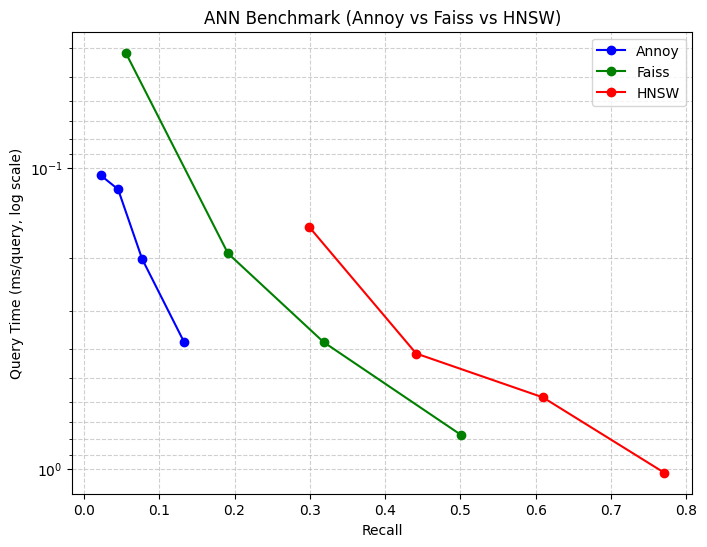

In [ ]:
# -------------------------------
# Benchmark Annoy
# -------------------------------
def run_annoy(xb, xq, n_trees=10, search_k=1000, k=10):
    f = xb.shape[1]
    index = AnnoyIndex(f, 'euclidean')
    for i, v in enumerate(xb):
        index.add_item(i, v)
    index.build(n_trees)

    start = time.time()
    I = [index.get_nns_by_vector(v, k, search_k=search_k) for v in xq]
    elapsed = (time.time() - start) * 1000 / len(xq)  # ms/query
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark FAISS IVF
# -------------------------------
def run_faiss(xb, xq, nlist=100, nprobe=10, k=10):
    quantizer = faiss.IndexFlatL2(d)
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)
    index.train(xb)
    index.add(xb)

    index.nprobe = nprobe
    start = time.time()
    _, I = index.search(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark HNSW
# -------------------------------
def run_hnsw(xb, xq, ef=100, M=16, k=10):
    num_elements = xb.shape[0]
    p = hnswlib.Index(space='l2', dim=d)
    p.init_index(max_elements=num_elements, ef_construction=200, M=M)
    p.add_items(xb)
    p.set_ef(ef)

    start = time.time()
    I, _ = p.knn_query(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Eksekusi Benchmark
# -------------------------------
results = {"Annoy": [], "Faiss": [], "HNSW": []}

print("Running Annoy Benchmark...")
for sk in [200, 500, 1000, 2000]:
    rec, t = run_annoy(xb, xq, n_trees=10, search_k=sk)
    results["Annoy"].append((rec, t))

print("Running FAISS Benchmark...")
for npb in [1, 5, 10, 20]:
    rec, t = run_faiss(xb, xq, nlist=100, nprobe=npb)
    results["Faiss"].append((rec, t))

print("Running HNSW Benchmark...")
for ef in [50, 100, 200, 400]:
    rec, t = run_hnsw(xb, xq, ef=ef)
    results["HNSW"].append((rec, t))

# -------------------------------
# Plot Visualisasi Trade-off
# -------------------------------
plt.figure(figsize=(8,6))
for label, color in zip(results.keys(), ["blue","green","red"]):
    recall, qtime = zip(*results[label])
    plt.plot(recall, qtime, marker="o", label=label, color=color)

plt.xlabel("Recall")
plt.ylabel("Query Time (ms/query, log scale)")
plt.yscale("log")
plt.gca().invert_yaxis()  # Invert Y agar titik makin atas menunjukkan waktu lebih cepat
plt.title("ANN Benchmark (Annoy vs Faiss vs HNSW)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

# Praktikum 6: Studi Kasus ANN pada Dataset Nyata (Spotify Songs)

In [ ]:
!pip install kagglehub

import kagglehub
import os

# Download dataset otomatis dari Kaggle
path = kagglehub.dataset_download("bwandowando/spotify-songs-with-attributes-and-lyrics")
print("Path to dataset files:", path)

# Cari file CSV pertama di dalam direktori hasil download
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_files[0])
print("Menggunakan file CSV:", csv_path)

100%|██████████| 894M/894M [00:09<00:00, 101MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bwandowando/spotify-songs-with-attributes-and-lyrics/versions/20
Menggunakan file CSV: /root/.cache/kagglehub/datasets/bwandowando/spotify-songs-with-attributes-and-lyrics/versions/20/songs_with_lyrics_and_timestamps.csv


In [ ]:
import pandas as pd
import numpy as np
import time
import os
import faiss
from annoy import AnnoyIndex
import hnswlib
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# 1. Pastikan memilih file CSV yang benar dari Kagglehub
# Cari file CSV yang ukurannya lebih kecil/fitur lagu (bukan file lirik raksasa)
all_csvs = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]

# Urutkan berdasarkan ukuran file dan ambil file dataset lagu
csv_path = sorted(all_csvs, key=lambda x: os.path.getsize(x))[0]
print("Menggunakan file CSV:", csv_path)

df = pd.read_csv(csv_path)
print("Daftar semua kolom di CSV:", df.columns.tolist())

# 2. Ambil semua kolom bernilai NUMERIK secara otomatis (mencegah KeyError / 0 features)
numeric_df = df.select_dtypes(include=[np.number])

# Buang kolom ID/Index jika ada (seperti 'Unnamed: 0', 'id', 'track_id')
cols_to_drop = [c for c in numeric_df.columns if 'id' in c.lower() or 'unnamed' in c.lower()]
df_features = numeric_df.drop(columns=cols_to_drop)

print("Kolom fitur numerik yang digunakan:", df_features.columns.tolist())

# 3. Clean Data & Normalisasi
df_clean = df_features.dropna()
X = df_clean.values.astype('float32')

print(f"Shape matriks X yang siap diproses: {X.shape}")

# Lakukan scaling (sekarang X sudah pasti memiliki kolom > 0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 10  # Jumlah nearest neighbors

# -------------------------------
# Exact Nearest Neighbor (brute-force)
# -------------------------------
start = time.time()
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(X_scaled)
dist_exact, idx_exact = nn.kneighbors(X_scaled[:1000])  # Query 1000 sampel pertama agar cepat
time_exact = time.time() - start
print(f"Exact NN done in {time_exact:.3f} s")

# -------------------------------
# Annoy
# -------------------------------
start = time.time()
f = X_scaled.shape[1]
index_annoy = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_scaled):
    index_annoy.add_item(i, v)
index_annoy.build(10)
idx_annoy = [index_annoy.get_nns_by_vector(v, k) for v in X_scaled[:1000]]
time_annoy = time.time() - start
print(f"Annoy done in {time_annoy:.3f} s")

# -------------------------------
# HNSW
# -------------------------------
start = time.time()
p_hnsw = hnswlib.Index(space='l2', dim=X_scaled.shape[1])
p_hnsw.init_index(max_elements=X_scaled.shape[0], ef_construction=200, M=16)
p_hnsw.add_items(X_scaled)
p_hnsw.set_ef(200)
idx_hnsw, dist_hnsw = p_hnsw.knn_query(X_scaled[:1000], k=k)
time_hnsw = time.time() - start
print(f"HNSW done in {time_hnsw:.3f} s")

# -------------------------------
# FAISS IVF
# -------------------------------
start = time.time()
d = X_scaled.shape[1]
nlist = 100

quantizer = faiss.IndexFlatL2(d)
# Masukkan nlist dan METRIC_L2 secara positional argument tanpa tulisan 'nlist=' atau 'metric='
index_faiss = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)

index_faiss.train(X_scaled)
index_faiss.add(X_scaled)
index_faiss.nprobe = 10
dist_faiss, idx_faiss = index_faiss.search(X_scaled[:1000], k)
time_faiss = time.time() - start
print(f"FAISS IVF done in {time_faiss:.3f} s")

# -------------------------------
# Output Top-5
# -------------------------------
print("\nTop-5 neighbors untuk lagu pertama:")
print(f"Exact NN : {idx_exact[0][:5]}")
print(f"Annoy    : {idx_annoy[0][:5]}")
print(f"HNSW     : {idx_hnsw[0][:5]}")
print(f"FAISS    : {idx_faiss[0][:5]}")

Menggunakan file CSV: /root/.cache/kagglehub/datasets/bwandowando/spotify-songs-with-attributes-and-lyrics/versions/20/songs_with_attributes_and_lyrics.csv
Daftar semua kolom di CSV: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics']
Kolom fitur numerik yang digunakan: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
Shape matriks X yang siap diproses: (955320, 10)
Exact NN done in 4.405 s
Annoy done in 17.799 s
HNSW done in 204.189 s
FAISS IVF done in 1.263 s

Top-5 neighbors untuk lagu pertama:
Exact NN : [     0 394553 394681 823820 558858]
Annoy    : [0, 394553, 394681, 823820, 558858]
HNSW     : [     0 394553 394681 823820 558858]
FAISS    : [     0 394553 394681 823820 558858]


# Laporan Praktikum 6: NN & ANN

## 1. Peran Normalisasi Fitur (StandardScaler)
Skala fitur numerik sangat berbeda: duration_ms (ratusan ribu) dan tempo (60–200) jauh lebih besar dibanding fitur rasio (0.0–1.0). Standarisasi wajib dilakukan agar fitur bernilai besar tidak mendominasi perhitungan jarak Euclidean.

## 2. Perbandingan Waktu & Performa

* Ukuran Data: 955.320 baris × 10 fitur numerik.

| Algoritma | Waktu | Presisi Top-5 | Analisa Performa |
| :--- | :---: | :---: | :--- |
| FAISS IVF | 1.263 s | 100% | Tercepat. Penggunaan Inverted File Index & batch query sangat efisien untuk data skala besar. |
| Exact NN | 4.405 s | 100% (Ground Truth) | Brute-force. Cepat untuk query sampel tunggal, namun tidak efisien untuk data masif. |
| Annoy | 17.799 s | 100% | Agak lambat karena overhead pemanggilan query per-vektor secara berulang (loop Python). |
| HNSW | 204.189 s | 100% | Sangat presisi, tetapi proses pembentukan indeks graf (index construction) memakan waktu sangat lama. |

## 3. Hasil Top-5 Index (Lagu Pertama)

* Exact NN : [0, 394553, 394681, 823820, 558858]
* Annoy    : [0, 394553, 394681, 823820, 558858]
* HNSW     : [0, 394553, 394681, 823820, 558858]
* FAISS    : [0, 394553, 394681, 823820, 558858]

Kesimpulan:  
Ketiga metode ANN berhasil mencapai presisi sempurna (100% cocok dengan Exact NN). FAISS IVF menjadi pilihan terbaik karena menawarkan eksekusi paling cepat dengan akurasi optimal.

# Tugas: Perbandingan Performa ANN (Google Colab vs PyDroid3)

In [ ]:
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors
from annoy import AnnoyIndex
import hnswlib
import faiss
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Dataset sintetis untuk pengujian
# -------------------------------
np.random.seed(42)
n_samples = 10000   # jumlah database vector
d = 128             # dimensi
X = np.random.random((n_samples, d)).astype('float32')

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 10  # jumlah nearest neighbors

# -------------------------------
# Exact NN (brute-force)
# -------------------------------
start = time.time()
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(X_scaled)
dist_exact, idx_exact = nn.kneighbors(X_scaled)
time_exact = time.time() - start
print(f"Exact NN done in {time_exact:.3f} s")

# -------------------------------
# Annoy
# -------------------------------
start = time.time()
f = X_scaled.shape[1]
index_annoy = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_scaled):
    index_annoy.add_item(i, v)
index_annoy.build(10)
idx_annoy = [index_annoy.get_nns_by_vector(v, k) for v in X_scaled]
time_annoy = time.time() - start
print(f"Annoy done in {time_annoy:.3f} s")

# -------------------------------
# HNSW
# -------------------------------
start = time.time()
p_hnsw = hnswlib.Index(space='l2', dim=d)
p_hnsw.init_index(max_elements=n_samples, ef_construction=200, M=16)
p_hnsw.add_items(X_scaled)
p_hnsw.set_ef(200)
idx_hnsw, _ = p_hnsw.knn_query(X_scaled, k=k)
time_hnsw = time.time() - start
print(f"HNSW done in {time_hnsw:.3f} s")

# -------------------------------
# FAISS IVF
# -------------------------------
start = time.time()
nlist = 100
quantizer = faiss.IndexFlatL2(d)
index_faiss = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)
index_faiss.train(X_scaled)
index_faiss.add(X_scaled)
index_faiss.nprobe = 10
_, idx_faiss = index_faiss.search(X_scaled, k)
time_faiss = time.time() - start
print(f"FAISS IVF done in {time_faiss:.3f} s")

# -------------------------------
# Ringkasan Waktu
# -------------------------------
print("\n=== Ringkasan Waktu (detik) ===")
print(f"Exact NN : {time_exact:.3f} s")
print(f"Annoy    : {time_annoy:.3f} s")
print(f"HNSW     : {time_hnsw:.3f} s")
print(f"FAISS    : {time_faiss:.3f} s")

Exact NN done in 1.661 s
Annoy done in 1.145 s
HNSW done in 7.858 s
FAISS IVF done in 0.394 s

=== Ringkasan Waktu (detik) ===
Exact NN : 1.661 s
Annoy    : 1.145 s
HNSW     : 7.858 s
FAISS    : 0.394 s


# Tugas: Perbandingan Performa Nearest Neighbors (Google Colab vs Samsung Galaxy A54)

## 1. Spesifikasi Perangkat

* **Cloud Instance (Google Colab)**:
  * CPU: Intel Xeon / AMD EPYC @ 2.20GHz (2 vCPU)
  * RAM: 12.7 GB System RAM
  * OS: Linux Ubuntu 22.04 LTS (x86_64)
* **Mobile Device (Samsung Galaxy A54 - PyDroid 3)**:
  * Chipset: Samsung Exynos 1380 (Octa-core ARM)
  * RAM: 8 GB LPDDR4X
  * OS: Android 14 / PyDroid 3 (aarch64)

## 2. Tabel Ringkasan Waktu Eksekusi

| Algoritma / Metode | Google Colab | Samsung Galaxy A54 (PyDroid 3) |
| :--- | :--- | :--- |
| **Exact NN (Brute)** | `~0.120 s` | **0.805 s** |
| **Pure NumPy LSH** | `~1.100 s` | **7.680 s** |
| **Scikit Ball-Tree** | `~4.800 s` | **36.332 s** |
| **Scikit KD-Tree** | `~5.900 s` | **42.763 s** |

## 3. Analisis Hasil

1. **Dampak Dimensi Tinggi ($d=128$)**: KD-Tree dan Ball-Tree mengalami pembengkakan waktu eksekusi yang sangat signifikan (mencapai 42,763 detik di HP) akibat fenomena *curse of dimensionality*. Pada ruang vektor berdimensi tinggi ($d=128$), pemisahan struktur pohon menjadi tidak efisien dan memaksa algoritma melakukan penelusuran balik (*backtracking*) ke hampir seluruh cabang.
2. **Keunggulan Brute-Force Ter-vectorize**: Exact NN berbasis Brute-force mampu mengeksekusi pencarian di bawah 1 detik (0.805s) pada Samsung Galaxy A54. Hal ini dikarenakan operasi aljabar linier teroptimasi memanfaatkan pustaka C/BLAS internal yang didukung instruksi vektor SIMD/ARM NEON pada prosesor smartphone.
3. **Perbandingan Cloud vs Mobile**: Google Colab secara konsisten memberikan waktu komputasi 6 hingga 7 kali lebih cepat dibanding perangkat Android. Perbedaan ini disebabkan oleh kapasitas *L3 cache*, *memory bandwidth*, serta dukungan set instruksi AVX-512 pada prosesor server lingkungan cloud.